# Popularity-Based Movie Recommender

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

# ── Load datasets ──────────────────────────────────────────────────
movies  = pd.read_csv("data/movies.csv")
credits = pd.read_csv("data/credits.csv")

# Align id column name so we can merge
credits.rename(columns={"movie_id": "id"}, inplace=True)
movies["id"]  = movies["id"].astype(str)
credits["id"] = credits["id"].astype(str)

df = movies.merge(credits, on="id", how="left", suffixes=("", "_c"))
print(f"Dataset shape after merge: {df.shape}")
df[["title","vote_average","vote_count","genres","overview"]].head(3)


Dataset shape after merge: (4803, 23)


,title,vote_average,vote_count,genres,overview
0,Avatar,7.2,11800,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,6.9,4500,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","Captain Barbossa, long believed to be dead, ha..."
2,Spectre,6.3,4466,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",A cryptic message from Bond’s past sends him o...


## 2. Parse Genres & Cast for Display

In [2]:
def safe_parse(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

def extract_names(val, limit=None):
    items = safe_parse(val)
    names = [i.get("name","") for i in items if isinstance(i, dict)]
    return names[:limit] if limit else names

df["genres_list"] = df["genres"].apply(extract_names)
df["cast_list"]   = df["cast"].apply(lambda x: extract_names(x, limit=5))

print("Sample genres:", df["genres_list"].iloc[0])
print("Sample cast  :", df["cast_list"].iloc[0])


Sample genres: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Sample cast  : ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez']


## 3. IMDB Weighted Rating Formula

IMDB uses a Bayesian average that prevents low-vote movies from dominating:

$$WR = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

| Symbol | Meaning |
|--------|---------|
| `v` | Number of votes for the movie |
| `m` | Minimum votes required to qualify (90th percentile) |
| `R` | Movie's own average rating |
| `C` | Mean rating across all movies |



In [3]:
m = df["vote_count"].quantile(0.90)   # 90th-percentile vote threshold
C = df["vote_average"].mean()          # global mean rating

print(f"Minimum votes required (m) : {m:.0f}")
print(f"Global mean rating     (C) : {C:.3f}")
print(f"Movies that qualify        : {(df['vote_count'] >= m).sum()} / {len(df)}")


Minimum votes required (m) : 1838
Global mean rating     (C) : 6.092
Movies that qualify        : 481 / 4803


In [4]:
def weighted_rating(row, m=m, C=C):
    v = row["vote_count"]
    R = row["vote_average"]
    return (v / (v + m)) * R + (m / (v + m)) * C

qualified = df[df["vote_count"] >= m].copy()
qualified["weighted_score"] = qualified.apply(weighted_rating, axis=1)
qualified.sort_values("weighted_score", ascending=False, inplace=True)
qualified.reset_index(drop=True, inplace=True)

display_cols = ["title", "weighted_score", "vote_average", "vote_count",
                "genres_list", "release_date"]
qualified[display_cols].head(10)


,title,weighted_score,vote_average,vote_count,genres_list,release_date
0,The Shawshank Redemption,8.059258,8.5,8205,"[Drama, Crime]",1994-09-23
1,Fight Club,7.939256,8.3,9413,[Drama],1999-10-15
2,The Dark Knight,7.920020,8.2,12002,"[Drama, Action, Crime, Thriller]",2008-07-16
3,Pulp Fiction,7.904645,8.3,8428,"[Thriller, Crime]",1994-10-08
4,Inception,7.863239,8.1,13752,"[Action, Thriller, Science Fiction, Mystery, A...",2010-07-14
5,The Godfather,7.851236,8.4,5893,"[Drama, Crime]",1972-03-14
6,Interstellar,7.809479,8.1,10867,"[Adventure, Drama, Science Fiction]",2014-11-05
7,Forrest Gump,7.803188,8.2,7927,"[Comedy, Drama, Romance]",1994-07-06
8,The Lord of the Rings: The Return of the King,7.727243,8.1,8064,"[Adventure, Fantasy, Action]",2003-12-01
9,The Empire Strikes Back,7.697884,8.2,5879,"[Adventure, Action, Science Fiction]",1980-05-17


## 4. Top-10 Visualisation

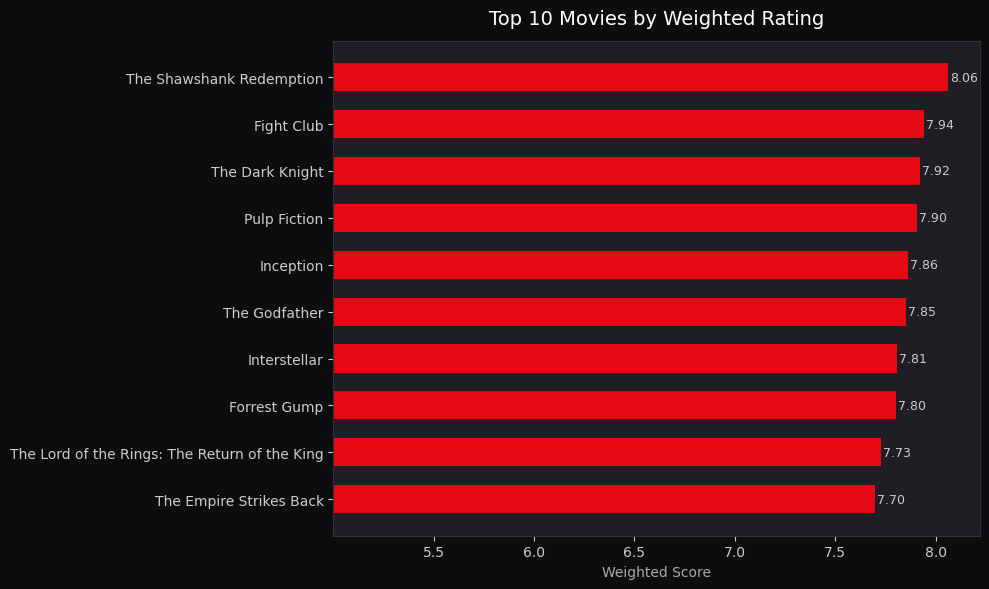

In [10]:
top10 = qualified.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10["title"][::-1], top10["weighted_score"][::-1],
               color="#e50914", edgecolor="none", height=0.6)

# Add score labels
for bar, score in zip(bars, top10["weighted_score"][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{score:.2f}", va="center", fontsize=9, color="#ccc")

ax.set_xlabel("Weighted Score", color="#aaa")
ax.set_title("Top 10 Movies by Weighted Rating", color="white", fontsize=14, pad=12)
ax.set_facecolor("#1e1e24")
fig.patch.set_facecolor("#0d0d0f")
ax.tick_params(colors="#ccc")
ax.spines[:].set_color("#333")
ax.xaxis.label.set_color("#aaa")
ax.set_xlim(qualified["weighted_score"].min() * 0.97, qualified["weighted_score"].max() * 1.02)
plt.tight_layout()
plt.show()


## 5. Genre-Level Filtering

In [9]:
def top_movies_by_genre(genre: str, n: int = 10):
    """Return top-n popular movies filtered by genre."""    
    filtered = qualified[
        qualified["genres_list"].apply(
            lambda g: genre.lower() in [x.lower() for x in g]
        )
    ]
    return filtered[display_cols].head(n)

# Try different genres
print("=== Top 5 Action movies ===")
display(top_movies_by_genre("Action", 5))

print("\n=== Top 5 Drama movies ===")
display(top_movies_by_genre("Drama", 5))


=== Top 5 Action movies ===


,title,weighted_score,vote_average,vote_count,genres_list,release_date
2,The Dark Knight,7.920020,8.2,12002,"[Drama, Action, Crime, Thriller]",2008-07-16
4,Inception,7.863239,8.1,13752,"[Action, Thriller, Science Fiction, Mystery, A...",2010-07-14
8,The Lord of the Rings: The Return of the King,7.727243,8.1,8064,"[Adventure, Fantasy, Action]",2003-12-01
9,The Empire Strikes Back,7.697884,8.2,5879,"[Adventure, Action, Science Fiction]",1980-05-17
10,The Lord of the Rings: The Fellowship of the Ring,7.667341,8.0,8705,"[Adventure, Fantasy, Action]",2001-12-18



=== Top 5 Drama movies ===


,title,weighted_score,vote_average,vote_count,genres_list,release_date
0,The Shawshank Redemption,8.059258,8.5,8205,"[Drama, Crime]",1994-09-23
1,Fight Club,7.939256,8.3,9413,[Drama],1999-10-15
2,The Dark Knight,7.920020,8.2,12002,"[Drama, Action, Crime, Thriller]",2008-07-16
5,The Godfather,7.851236,8.4,5893,"[Drama, Crime]",1972-03-14
6,Interstellar,7.809479,8.1,10867,"[Adventure, Drama, Science Fiction]",2014-11-05


## 6. All Unique Genres

In [7]:
all_genres = set()
for g_list in qualified["genres_list"]:
    all_genres.update(g_list)

print("Available genres:")
print(sorted(all_genres))


Available genres:
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War', 'Western']
